# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



### Установка зависимостей

In [3]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [4]:
import PIL
print(PIL.__version__)

11.0.0


В нашем тесте будет 990 картнок, для которых вам будет необходимо предсказать класс.

In [5]:
import pickle
import numpy as np
from skimage import io

from tqdm.notebook import tqdm
from PIL import Image
from pathlib import Path

from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)


In [6]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']
# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = 224
# работаем на видеокарте

https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/


Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.

ToTensor конвертирует  PIL Image с параметрами в диапазоне [0, 255] (как все пиксели) в FloatTensor размера (C x H x W) [0,1] , затем производится масштабирование:
$input = \frac{input - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet


Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размер (это делает метод  _prepare_sample)

In [7]:
img = Image.open("/kaggle/input/journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0000.jpg")
img = np.array(img)
print(img.size * img.itemsize / 1024**2 * 20000)

13710.9375


In [8]:
class SimpsonsDataset(Dataset):
    """
    Датасет с картинками, который паралельно подгружает их из папок
    производит скалирование и превращение в торчевые тензоры
    """
    def __init__(self, files, mode):
        super().__init__()
        # список файлов для загрузки
        # режим работы
        files = sorted(files)
        self.mode = mode

        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.len_ = len(files)
        
        if self.mode != 'test':
            self.labels = [path.parent.name for path in files]
            self.label_encoder = LabelEncoder().fit(self.labels)
            with open('label_encoder.pkl', 'wb') as le_dump_file:
                  pickle.dump(self.label_encoder, le_dump_file)
        
        self.train_transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.RandomHorizontalFlip(),
            transforms.RandomResizedCrop(224, scale=(0.5, 1)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        self.val_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        self.X = [ self._prepare_sample(file) for file in files ]

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        if self.mode == 'test':
            return self.X[index]
        else:
            label = self.labels[index]
            label_id = self.label_encoder.transform([label])
            y = label_id.item()
            return self.X[index], y

    def _prepare_sample(self, file):
        image = self.load_sample(file)
        image = image.resize((RESCALE_SIZE, RESCALE_SIZE))
        trans = self.train_transform if self.mode == 'train' else self.val_transform
        return trans(image)

In [9]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

In [10]:
#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('/kaggle/input/journey-springfield/train/')
TEST_DIR = Path('/kaggle/input/journey-springfield/testset')

In [11]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

In [12]:
from sklearn.model_selection import train_test_split

train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels)

In [13]:
val_dataset = SimpsonsDataset(val_files, mode='val')

In [14]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

Давайте посмотрим на наших героев внутри датасета.

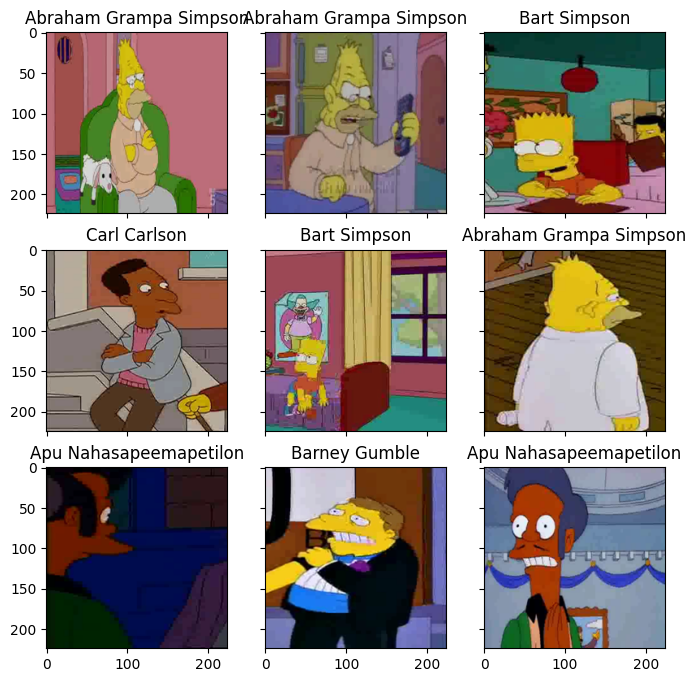

In [15]:
fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(8, 8), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))
    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

Можете добавить ваши любимые сцены и классифицировать их. (веселые результаты можно кидать в чат)

### Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle

<!-- Здесь вам предлагается дописать сверточную сеть глубины 4/5.  -->

*Описание слоев*:



1. размерность входа: 3x224x224
2.размерности после слоя:  8x111x111
3. 16x54x54
4. 32x26x26
5. 64x12x12
6. выход: 96x5x5


In [16]:
# Очень простая сеть
class SimpleCnn(nn.Module):

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            # nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            # nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            # nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            # nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            # nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = nn.Flatten()(x)
        logits = self.out(x)
        return logits

In [17]:
import math as m
from tqdm.notebook import tqdm

In [18]:
def fit_epoch(model, train_loader, criterion, optimizer):
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0

    with tqdm(desc="train batches", total=len(train_loader)) as bar:
        for inputs, labels in train_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
    
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            preds = torch.argmax(outputs, dim=-1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            processed_data += inputs.size(0)
            bar.update(1)

    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

In [19]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0

    with tqdm(desc="val batches", total=len(val_loader)) as bar:
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
    
            with torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                preds = torch.argmax(outputs, 1)
    
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            processed_size += inputs.size(0)
            bar.update(1)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.cpu().numpy() / processed_size
    return val_loss, val_acc

In [20]:
from IPython.display import clear_output
import time

In [21]:
def train(train_loader, val_loader, model, opt, criterion, schedulers=None, milestones=None, epochs=10):
    global general

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    metric_names = ["loss", "accuracy"]
    # log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    # val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:

        fig, axs = plt.subplots(1, 2, figsize=(10, 8))
        plt.ylim(0.9, 1.0)  # Установка диапазона по оси Y
        plt.grid(True)      # Включение сетки для удобства чтения
        
        for epoch in range(epochs):
            print(f"Epoch: {epoch}/{epochs}")
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, opt)
            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            if schedulers is not None:
                scheduler = schedulers[0] if epoch < milestones[0] else schedulers[1]
                try:
                    scheduler.step()
                except:
                    scheduler.step(val_acc)
            lrs.append(opt.param_groups[0]['lr'])
            # print(type(train_loss), type(val_acc))
            # history.append((train_loss, train_acc, val_loss, val_acc))
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            general["train_loss"].append(train_loss)
            general["train_acc"].append(train_acc)
            general["val_loss"].append(val_loss)
            general["val_acc"].append(val_acc)

            pbar_outer.update(1)            
            clear_output()
            print(lrs)
            print(f'train accuracy: {history["train_acc"][-1]}')
            print(f'validation accuracy: {history["val_acc"][-1]}')


            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            # plt.cla()
            plt.plot(history['train_loss'], label='Train Loss', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Loss', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Loss', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=12)
            
            # График точности
            plt.subplot(1, 2, 2)
            # plt.cla()
            plt.plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Accuracy', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Accuracy', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=12)
            
            plt.tight_layout()
            plt.show()

    return history

In [22]:
def predict(model, test_loader):
    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

In [23]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [24]:
n_classes = len(np.unique(train_val_labels))
simple_cnn = SimpleCnn(n_classes).to(DEVICE)
print("we will classify :{}".format(n_classes))
print(simple_cnn)

we will classify :42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv5): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=2400, out_fea

Запустим обучение сети.

In [25]:
if val_dataset is None:
    val_dataset = SimpsonsDataset(val_files, mode='val')

train_dataset = SimpsonsDataset(train_files, mode='train')
batch_size=128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

In [26]:
import torchvision
import torchvision.models as models

In [27]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s] 


In [28]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s] 


In [29]:
in_ftr = model.fc.in_features
model.fc = nn.Linear(in_ftr, 42)

In [30]:
lrs = []
general = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
def warmup(num, lr_st, lr_end):
    def lambda_lr(epoch):
        return lr_st + (lr_end - lr_st) * min(1, (epoch + 1) / num)
    return lambda_lr

In [31]:
st = 1e-5
for i in range(10):
    print(st)
    st *= 1.9

1e-05
1.9e-05
3.61e-05
6.859e-05
0.000130321
0.0002476099
0.00047045881
0.0008938717389999999
0.0016983563040999998
0.0032268769777899996


In [52]:
model = model.to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
# scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=warmup(11, 1e-5, 3e-3))
scheduler1 = torch.optim.lr_scheduler.StepLR(opt, step_size=1, gamma=1.65)
scheduler2 = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.55)
# scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.55, patience=2, min_lr=1e-6)
# scheduler = torch.optim.lr_scheduler.SequentialLR(opt, [scheduler1, scheduler2], milestones=[10])
criterion = nn.CrossEntropyLoss()

[1.65e-05, 2.7225e-05, 4.4921249999999996e-05, 7.41200625e-05, 0.00012229810312499998, 0.00020179187015624994, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.00018312612216679684, 1.65e-05, 2.7225e-05, 4.4921249999999996e-05, 7.41200625e-05, 0.00012229810312499998, 0.00020179187015624994, 0.0003329565857578124, 0.0003329565857578124, 0.0003329565857578124, 0.00018312612216679684, 0.00018312612216679684, 0.00018312612216679684, 0.00010071936719173827, 0.00010071936719173827]
train accuracy: 1.0
validation accuracy: 0.9713412304165074


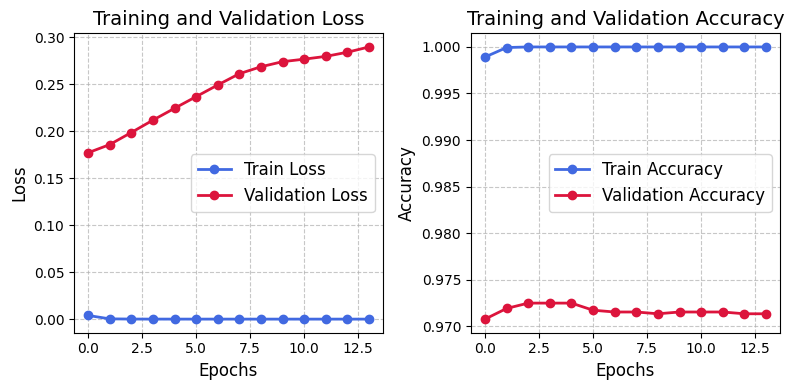

Epoch: 14/30


train batches:   0%|          | 0/123 [00:00<?, ?it/s]

In [ ]:
history = train(train_loader, val_loader, model, opt, criterion, schedulers=[scheduler1, scheduler2], milestones=[7], epochs=30)

Построим кривые обучения

In [34]:
general

{'train_loss': [3.5516080587667616,
  1.4096040763105662,
  0.3691361113083318,
  0.17876594398282,
  0.13720915499507252,
  0.16386740957257762,
  0.21216566150594998,
  0.22755580798813746,
  0.1298019565066203,
  0.09015265732023114,
  0.07482087076625306,
  0.055736659474481524,
  0.03449831279702411,
  0.041986124001666916,
  0.050952909355201845,
  0.03404925059339933,
  0.051594695708618264,
  0.04883229545585971,
  0.03426806084950564],
 'train_acc': [0.10350977769284668,
  0.6650105102235812,
  0.9058538760430601,
  0.9524810497483917,
  0.9618447034842984,
  0.9521625581247213,
  0.9446461558061023,
  0.9398687814510478,
  0.9642652398241927,
  0.9740110835085037,
  0.9789795528377604,
  0.9846487037390916,
  0.9901267596662208,
  0.9884706032231352,
  0.9866233518058475,
  0.9905726479393592,
  0.9860500668832409,
  0.9868144467800497,
  0.9901267596662208],
 'val_loss': [3.263308222894228,
  0.5515377320631069,
  0.3430342891993393,
  0.3299883073597953,
  0.369229775487260

In [35]:
loss, acc, val_loss, val_acc = general["train_loss"], general["train_acc"], general["val_loss"], general["val_acc"]

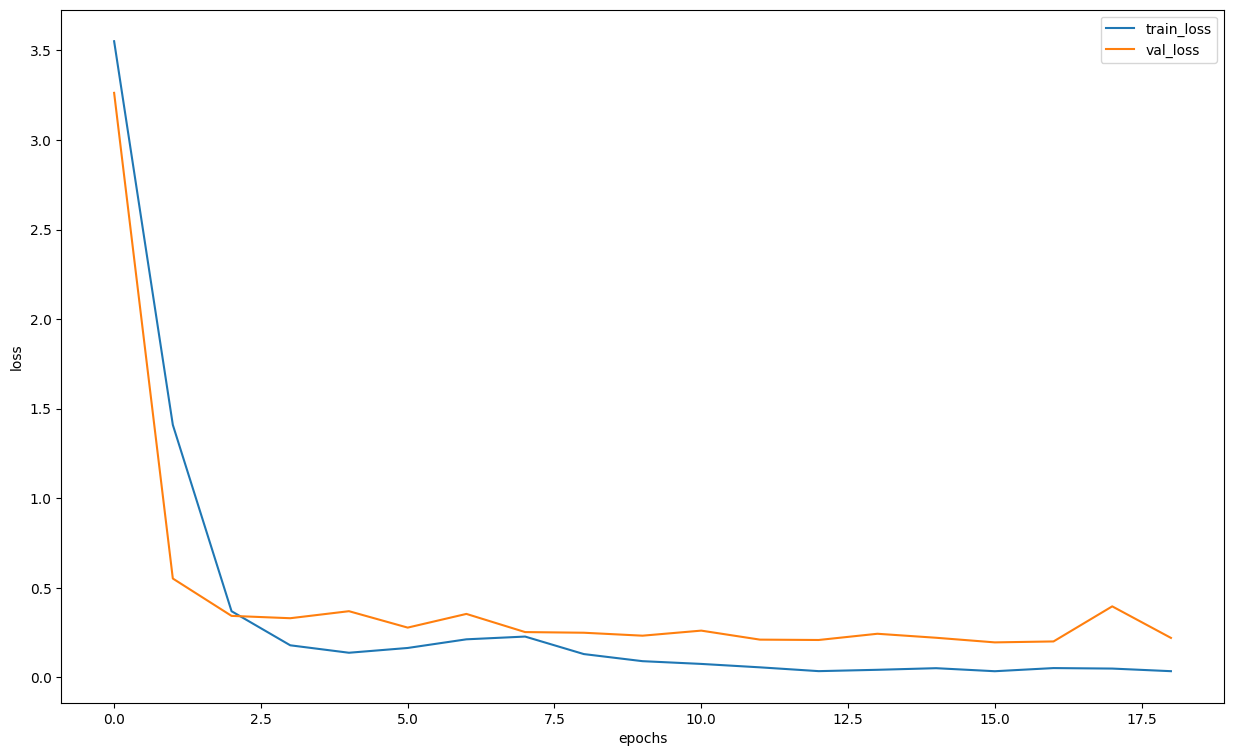

In [36]:
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Хорошо бы понять, как сделать сабмит.
У нас есть сеть и методы eval у нее, которые позволяют перевести сеть в режим предсказания. Стоит понимать, что у нашей модели на последнем слое стоит softmax, которые позволяет получить вектор вероятностей  того, что объект относится к тому или иному классу. Давайте воспользуемся этим.

In [37]:
tr = transforms.RandomRotation(20)
# tr = transforms.RandomHorizontalFlip(p=0.5)
# tr = transforms.RandomResizedCrop(256)
# tr = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)

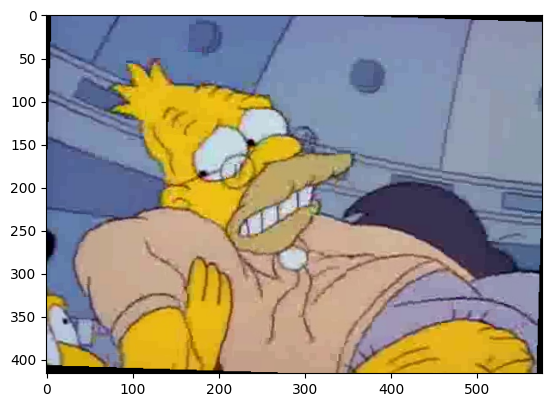

In [38]:
image = Image.open('/kaggle/input/journey-springfield/train/simpsons_dataset/abraham_grampa_simpson/pic_0000.jpg')
plt.imshow(tr(image))
plt.show()

In [39]:
def predict_one_sample(model, inputs, device=DEVICE):
    """Предсказание, для одной картинки"""
    with torch.no_grad():
        inputs = inputs.to(device)
        model.eval()
        logit = model(inputs).cpu()
        probs = torch.nn.functional.softmax(logit, dim=-1).numpy()
    return probs

In [40]:
random_characters = int(np.random.uniform(0,1000))
ex_img, true_label = val_dataset[random_characters]
probs_im = predict_one_sample(simple_cnn, ex_img.unsqueeze(0))

In [41]:
idxs = list(map(int, np.random.uniform(0,1000, len(val_dataset))))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]

probs_ims = predict(model, imgs)
probs_ims.shape

(5234, 42)

In [42]:
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))
label_encoder.classes_

array(['abraham_grampa_simpson', 'agnes_skinner',
       'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson',
       'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum',
       'cletus_spuckler', 'comic_book_guy', 'disco_stu', 'edna_krabappel',
       'fat_tony', 'gil', 'groundskeeper_willie', 'homer_simpson',
       'kent_brockman', 'krusty_the_clown', 'lenny_leonard',
       'lionel_hutz', 'lisa_simpson', 'maggie_simpson', 'marge_simpson',
       'martin_prince', 'mayor_quimby', 'milhouse_van_houten',
       'miss_hoover', 'moe_szyslak', 'ned_flanders', 'nelson_muntz',
       'otto_mann', 'patty_bouvier', 'principal_skinner',
       'professor_john_frink', 'rainier_wolfcastle', 'ralph_wiggum',
       'selma_bouvier', 'sideshow_bob', 'sideshow_mel', 'snake_jailbird',
       'troy_mcclure', 'waylon_smithers'], dtype='<U24')

In [43]:
y_pred = np.argmax(probs_ims,-1)

actual_labels = [val_dataset[idx][1] for idx in idxs]

preds_class = [label_encoder.classes_[i] for i in y_pred]

In [44]:
y_pred[:10], actual_labels[:10]

(array([4, 4, 6, 4, 2, 0, 4, 4, 6, 4]), [4, 4, 6, 4, 2, 0, 4, 4, 6, 4])

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе --- f1-score. Вычислим целевую метрику на валидационной выборке.

In [45]:
from sklearn.metrics import f1_score, accuracy_score
print("accuracy: ", accuracy_score(actual_labels, y_pred))
f1 = f1_score(actual_labels, y_pred, average='micro')

print("F1-оценка:", f1)


accuracy:  0.9589224302636606
F1-оценка: 0.9589224302636606


Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах. Можете исспользовать это, чтобы отлаживать правильность вывода.

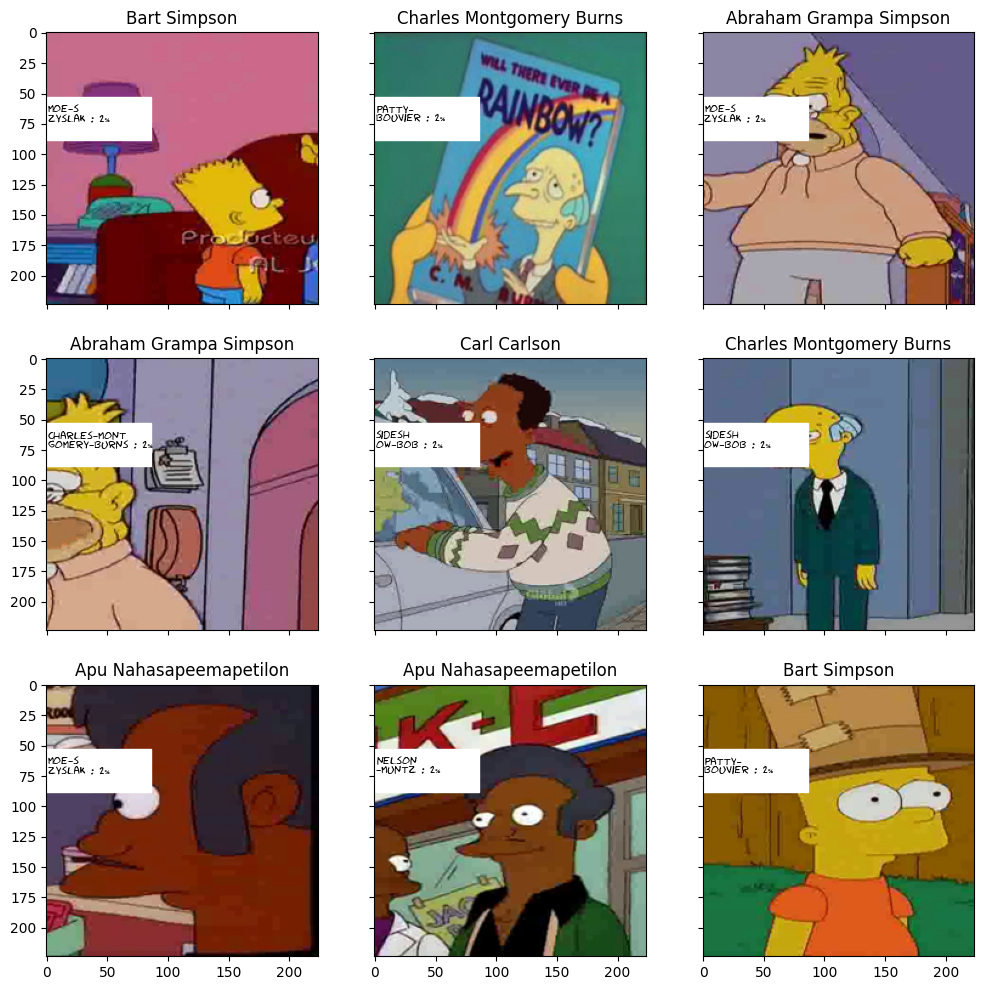

In [46]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

fig, ax = plt.subplots(nrows=3, ncols=3,figsize=(12, 12), \
                        sharey=True, sharex=True)
for fig_x in ax.flatten():
    random_characters = int(np.random.uniform(0,1000))
    im_val, label = val_dataset[random_characters]
    img_label = " ".join(map(lambda x: x.capitalize(),\
                val_dataset.label_encoder.inverse_transform([label])[0].split('_')))



    imshow(im_val.data.cpu(), \
          title=img_label,plt_ax=fig_x)

    actual_text = "Actual : {}".format(img_label)

    fig_x.add_patch(patches.Rectangle((0, 53),86,35,color='white'))
    font0 = FontProperties()
    font = font0.copy()
    font.set_family("fantasy")
    prob_pred = predict_one_sample(simple_cnn, im_val.unsqueeze(0))
    predicted_proba = np.max(prob_pred)*100
    y_pred = np.argmax(prob_pred)

    predicted_label = label_encoder.classes_[y_pred]
    predicted_label = predicted_label[:len(predicted_label)//2] + '\n' + predicted_label[len(predicted_label)//2:]
    predicted_text = "{} : {:.0f}%".format(predicted_label,predicted_proba)

    fig_x.text(1, 59, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')

Попробуйте найти те классы, которые сеть не смогла расспознать. Изучите данную проблему, это понадобится в дальнейшем.

### Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

In [47]:
test_dataset = SimpsonsDataset(test_files, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)
probs = predict(model, test_loader)


preds = label_encoder.inverse_transform(np.argmax(probs, axis=1))
test_filenames = [path.name for path in sorted(test_files)]


In [48]:
! ls

label_encoder.pkl


In [49]:
import pandas as pd
# my_submit = pd.read_csv("sample_submission.csv")
my_submit = pd.DataFrame({'Id': test_filenames, 'Expected': preds})
my_submit.head()

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon


In [50]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут-ho

In [51]:
my_submit.to_csv('ho-ho.csv', index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся скор нас явно не устраивает. Надо с этим что-то сделать.

Несколько срочныйх улучшейни для нашей сети, которые наверняка пришли Вам в голову:


*   Учим дольше и изменяем гиперпараметры сети
*  learning rate, batch size, нормализация картинки и вот это всё
*   Кто же так строит нейронные сети? А где пулинги и батч нормы? Надо добавлять
*  Ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

* Ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

* Данных не очень много, можно их аугументировать и  доучититься на новом датасете ( который уже будет состоять из, как  пример аугументации, перевернутых изображений)

* Стоит подумать об ансамблях


Надеюсь, что у Вас получится!

![alt text](https://pbs.twimg.com/profile_images/798904974986113024/adcQiVdV.jpg)
